## Training on APTOS

In [ ]:
import sys, subprocess

def run_live(cmd):
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd)

TRAIN_PY = r"C:\Users\Mohammad\Documents\train_dr_qwen3vl_runsave.py"

SPLIT_DIR = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports"
TRAIN_CSV = rf"{SPLIT_DIR}\train_split.csv"
VAL_CSV   = rf"{SPLIT_DIR}\val_split.csv"
TEST_CSV  = rf"{SPLIT_DIR}\test_split.csv"

IMAGE_DIR = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\images"

TEMP_OUTPUT_DIR = rf"{SPLIT_DIR}\temp_training_output"
RUNS_ROOT       = rf"{SPLIT_DIR}\runs"
CACHE_DIR       = rf"{SPLIT_DIR}\cache"

cmd = [
    sys.executable, "-u", TRAIN_PY,
    "--csv_path", TRAIN_CSV,
    "--val_csv", VAL_CSV,
    "--test_csv", TEST_CSV,
    "--image_dir", IMAGE_DIR,
    "--ext", ".png",
    "--img_size", "512",

    "--model_name", "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    "--output_dir", TEMP_OUTPUT_DIR,
    "--runs_root", RUNS_ROOT,

    "--cache_dir", CACHE_DIR,
    "--preproc_num_proc", "1",

    "--epochs", "50",
    "--batch_size", "4",
    "--grad_accum", "2",
    "--lr", "5e-4",
    "--warmup_steps", "20",
    "--max_length", "2048",

    "--lora_r", "16",
    "--lora_alpha", "16",
    "--lora_dropout", "0.05",

    "--eval_strategy", "epoch",
    "--save_strategy", "epoch",
    "--save_total_limit", "2",

    "--early_stopping",
    "--early_stopping_patience", "2",
    "--early_stopping_threshold", "0.0",

    "--load_in_4bit",
]

run_live(cmd)

Streaming output truncated to the last 5000 lines.
  0%|          | 85/18350 [03:48<13:17:16,  2.62s/it]
                                                     
{'loss': '0.01896', 'grad_norm': '0.02365', 'learning_rate': '0.0004983', 'epoch': '0.2319'}

  0%|          | 90/18350 [04:00<12:58:10,  2.56s/it]
                                                     
{'loss': '0.01986', 'grad_norm': '0.01896', 'learning_rate': '0.0004981', 'epoch': '0.2456'}

  1%|          | 95/18350 [04:13<13:03:37,  2.58s/it]
                                                     
{'loss': '0.01979', 'grad_norm': '0.0315', 'learning_rate': '0.000498', 'epoch': '0.2592'}

  1%|          | 100/18350 [04:26<13:13:17,  2.61s/it]
                                                      
{'loss': '0.01837', 'grad_norm': '0.02696', 'learning_rate': '0.0004978', 'epoch': '0.2729'}

  1%|          | 105/18350 [04:39<12:56:34,  2.55s/it]
                                                      
{'loss': '0.01616', 'grad_norm'

## Evaluation

### Aptos evaluation (Aptos Training)

In [ ]:
import os
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Disable torch.compile/inductor for this notebook eval to avoid dtype mismatches
os.environ["UNSLOTH_DISABLE_COMPILE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"

import torch
from pathlib import Path

import unsloth
from unsloth import FastVisionModel
from peft import PeftModel

base_model_hf = "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"
RUN_PATH = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\runs\lr0.0005_epoch4_batchsize8"

run_p = Path(RUN_PATH)
lora_dir = run_p if (run_p / "adapter_config.json").exists() else (run_p / "best_lora")
assert (lora_dir / "adapter_config.json").exists(), f"Missing adapter_config.json in: {lora_dir}"
print("Using LoRA dir:", lora_dir)

model, tokenizer = FastVisionModel.from_pretrained(
    model_name=base_model_hf,
    load_in_4bit=True,
)

model = PeftModel.from_pretrained(model, str(lora_dir))

# Force inference mode and force fp16 to avoid bf16 mismatch paths
FastVisionModel.for_inference(model)
model = model.half()
model.eval()

print("Loaded Unsloth base + processor + LoRA (forced fp16, compile disabled)")
print("Device:", next(model.parameters()).device)
print("Model dtype sample:", next(model.parameters()).dtype)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0319 14:06:10.299000 29188 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken?
A possible explanation is you have a new CUDA version which isn't
yet compatible with FA2? Please file a ticket to Unsloth or FA2.
We shall now use Xformers instead, which does not have any performance hits!
We found this negligible impact by benchmarking on 1x A100.
🦥 Unsloth Zoo will now patch everything to make training faster!
Using LoRA dir: C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\runs\lr0.0005_epoch4_batchsize8\best_lora
==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 5.3.0.dev0.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.92 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are r

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loaded Unsloth base + processor + LoRA (forced fp16, compile disabled)
Device: cuda:0
Model dtype sample: torch.bfloat16


In [ ]:
import pandas as pd
from pathlib import Path

# ----- YOU SET THESE -----
eval_list_csv = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\test_split.csv"
images_dir    = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\images"
ext = ".png"
# -------------------------

df = pd.read_csv(eval_list_csv)
cols = set(df.columns)

# label column
label_col = None
for c in ["diagnosis", "dr_grade", "grade", "label", "y", "target", "class"]:
    if c in cols:
        label_col = c
        break
if label_col is None:
    raise ValueError(f"No label column found. Columns={df.columns.tolist()}")

# image path logic:
# - if image_path exists: use it (if relative, join images_dir)
# - else: use filename or id_code and build the path
if "image_path" in cols:
    def to_abs(p):
        p = str(p)
        pp = Path(p)
        return str(pp) if pp.is_absolute() else str(Path(images_dir) / p)
    df["image_path"] = df["image_path"].astype(str).map(to_abs)

else:
    id_col = None
    for c in ["filename", "id_code", "image", "image_id", "file", "path"]:
        if c in cols:
            id_col = c
            break
    if id_col is None:
        raise ValueError(f"No image id/path column found. Columns={df.columns.tolist()}")

    def build_path(v):
        v = str(v)
        pv = Path(v)
        if pv.is_absolute():
            return str(pv)
        if pv.suffix == "":
            return str(Path(images_dir) / f"{v}{ext}")
        return str(Path(images_dir) / v)

    df["image_path"] = df[id_col].astype(str).map(build_path)

df["y_true"] = df[label_col].astype(int)

df_list = df[["image_path", "y_true"]].copy()
missing = df_list["image_path"].map(lambda p: not Path(p).exists()).sum()
print("Rows:", len(df_list), "| Missing image files:", int(missing))

if missing:
    df_list = df_list[df_list["image_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)
    print("After dropping missing:", len(df_list))

Rows: 367 | Missing image files: 0


In [ ]:
import numpy as np
from PIL import Image
import torch

INSTRUCTION = (
    "You are a medical imaging assistant.\n"
    "Grade diabetic retinopathy severity from this retinal fundus image.\n\n"
    "Scale:\n"
    "0 - No DR\n"
    "1 - Mild\n"
    "2 - Moderate\n"
    "3 - Severe\n"
    "4 - Proliferative DR\n\n"
    "Return exactly this format:\n"
    "<answer>X - LABEL</answer>"
)

CANDIDATES = [
    "<answer>0 - No DR</answer>",
    "<answer>1 - Mild</answer>",
    "<answer>2 - Moderate</answer>",
    "<answer>3 - Severe</answer>",
    "<answer>4 - Proliferative DR</answer>",
]

def probs_by_full_answer_logprob(image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")

    prompt_messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": INSTRUCTION},
            {"type": "image", "image": img},
        ],
    }]

    prompt_only_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )

    prompt_only = tokenizer(images=img, text=prompt_only_text, return_tensors="pt").to(model.device)
    # ---- ADD THIS (1) ----
    if "pixel_values" in prompt_only:
        prompt_only["pixel_values"] = prompt_only["pixel_values"].to(dtype=torch.float16)
    # ----------------------
    prompt_len = prompt_only["input_ids"].shape[1]

    scores = []
    with torch.no_grad():
        for cand in CANDIDATES:
            messages = prompt_messages + [
                {"role": "assistant", "content": [{"type": "text", "text": cand}]}
            ]
            full_text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )

            batch = tokenizer(images=img, text=full_text, return_tensors="pt").to(model.device)
            # ---- ADD THIS (2) ----
            if "pixel_values" in batch:
                batch["pixel_values"] = batch["pixel_values"].to(dtype=torch.float16)
            # ----------------------

            labels = batch["input_ids"].clone()
            labels[:, :prompt_len] = -100

            # If you already did model = model.half(), you can just do:
            out = model(**batch, labels=labels)

            n = int((labels != -100).sum().item())
            total_logprob = -float(out.loss.item()) * max(n, 1)
            scores.append(total_logprob)

    scores = np.array(scores, dtype=np.float64)
    scores = scores - scores.max()
    probs = np.exp(scores) / np.exp(scores).sum()
    return probs

In [ ]:
import pandas as pd
import numpy as np

preds_csv = str(Path(eval_list_csv).with_name("preds_with_probs_quick.csv"))

df_run = df_list.head(30).copy()

rows = []
for idx, r in df_run.iterrows():
    probs = probs_by_full_answer_logprob(r["image_path"])
    y_pred = int(np.argmax(probs))

    row = {"image_path": r["image_path"], "y_true": int(r["y_true"]), "y_pred": y_pred}
    for k in range(5):
        row[f"p{k}"] = float(probs[k])
    rows.append(row)

    if (len(rows) % 10) == 0:
        print("Processed", len(rows), "/", len(df_run))

pd.DataFrame(rows).to_csv(preds_csv, index=False)
print("Saved:", preds_csv)

Processed 10 / 30
Processed 20 / 30
Processed 30 / 30
Saved: C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\preds_with_probs_quick.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

preds_csv = str(Path(eval_list_csv).with_name("preds_with_probs.csv"))

rows = []
for idx, r in df_list.iterrows():
    probs = probs_by_full_answer_logprob(r["image_path"])
    y_pred = int(np.argmax(probs))

    row = {"image_path": r["image_path"], "y_true": int(r["y_true"]), "y_pred": y_pred}
    for k in range(5):
        row[f"p{k}"] = float(probs[k])
    rows.append(row)

    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(df_list)}")

df_preds = pd.DataFrame(rows)
df_preds.to_csv(preds_csv, index=False)
print("Saved:", preds_csv)

Processed 20/367
Processed 40/367
Processed 60/367
Processed 80/367
Processed 100/367
Processed 120/367
Processed 140/367
Processed 160/367
Processed 180/367
Processed 200/367
Processed 220/367
Processed 240/367
Processed 260/367
Processed 280/367
Processed 300/367
Processed 320/367
Processed 340/367
Processed 360/367
Saved: C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\preds_with_probs.csv



Accuracy: 0.8174
QWK: 0.9292

Confusion matrix (rows=true, cols=pred):
 [[176   4   1   0   0]
 [  2  25  10   0   0]
 [  0   8  71  19   2]
 [  0   0   4  11   4]
 [  0   0   4   9  17]]

Classification report:
               precision    recall  f1-score   support

           0     0.9888    0.9724    0.9805       181
           1     0.6757    0.6757    0.6757        37
           2     0.7889    0.7100    0.7474       100
           3     0.2821    0.5789    0.3793        19
           4     0.7391    0.5667    0.6415        30

    accuracy                         0.8174       367
   macro avg     0.6949    0.7007    0.6849       367
weighted avg     0.8457    0.8174    0.8274       367



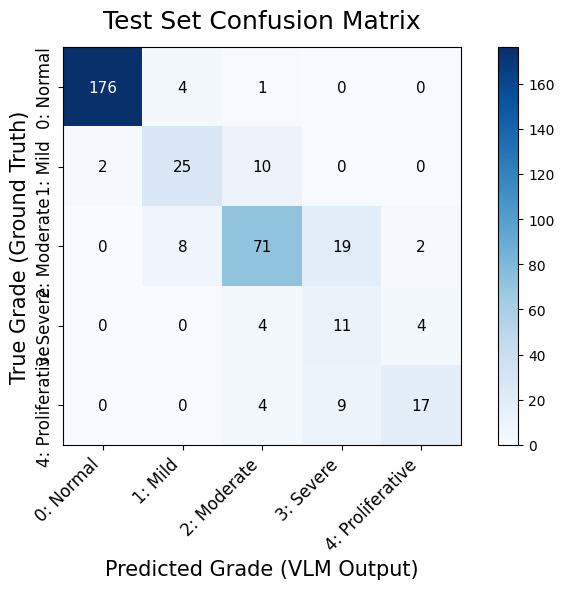

Saved confusion matrix image to: C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\confusion_matrix.png


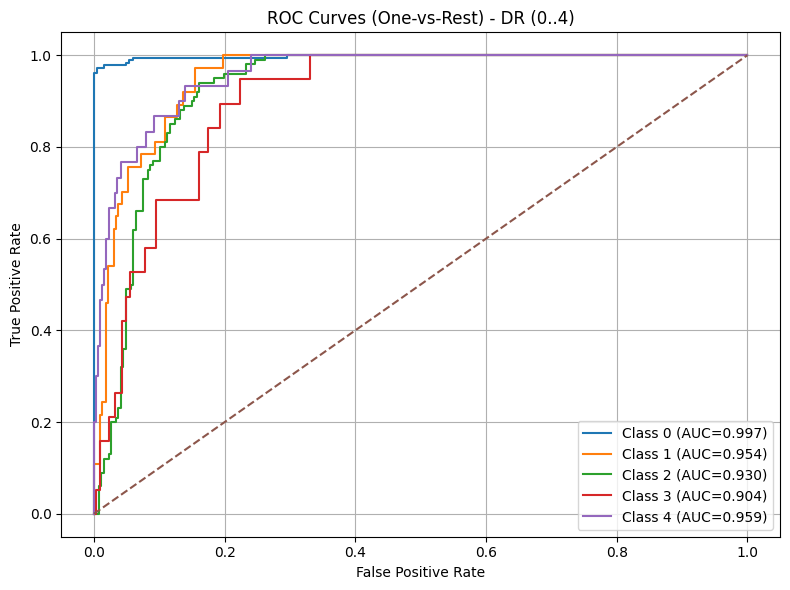


--- Summary (Macro / DR) ---
Accuracy:      0.8174
QWK:           0.9292
AUC-ROC:       0.9488
Precision:     0.6949
Recall:        0.7007
F1 Score:      0.6849


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

df_preds = pd.read_csv(preds_csv)

y_true = df_preds["y_true"].astype(int).to_numpy()
y_score = df_preds[[f"p{i}" for i in range(5)]].to_numpy()
y_pred = y_score.argmax(axis=1)

acc = accuracy_score(y_true, y_pred)
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])

print("\nAccuracy:", round(acc, 4))
print("QWK:", round(qwk, 4))
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)
print(
    "\nClassification report:\n",
    classification_report(y_true, y_pred, labels=[0, 1, 2, 3, 4], digits=4),
)

# Confusion matrix image
class_names = [
    "0: Normal",
    "1: Mild",
    "2: Moderate",
    "3: Severe",
    "4: Proliferative",
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax)

ax.set_title("Test Set Confusion Matrix", fontsize=18, pad=14)
ax.set_xlabel("Predicted Grade (VLM Output)", fontsize=15)
ax.set_ylabel("True Grade (Ground Truth)", fontsize=15)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(class_names, rotation=90, va="center", fontsize=12)

threshold = cm.max() / 2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=11,
        )

fig.tight_layout()
cm_img_path = Path(preds_csv).with_name("confusion_matrix.png")
plt.savefig(cm_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix image to: {cm_img_path}")

# ROC curves (OvR)
y_true_oh = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
for i in range(5):
    if len(np.unique(y_true_oh[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - DR (0..4)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Macro AUC
aucs = []
for i in range(5):
    if len(np.unique(y_true_oh[:, i])) < 2:
        continue
    aucs.append(roc_auc_score(y_true_oh[:, i], y_score[:, i]))

macro_ovr_auc = float(np.mean(aucs)) if len(aucs) else float("nan")

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    digits=4,
    output_dict=True,
)

print("\n--- Summary (Macro / DR) ---")
print(f"Accuracy:      {acc:.4f}")
print(f"QWK:           {qwk:.4f}")
print(f"AUC-ROC:       {macro_ovr_auc:.4f}")
print(f"Precision:     {report['macro avg']['precision']:.4f}")
print(f"Recall:        {report['macro avg']['recall']:.4f}")
print(f"F1 Score:      {report['macro avg']['f1-score']:.4f}")

### Messidor (APTOS training)

if you have run the section above then you can skip the following cell

In [ ]:
import os
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Disable torch.compile/inductor for this notebook eval to avoid dtype mismatches
os.environ["UNSLOTH_DISABLE_COMPILE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"

import torch
from pathlib import Path

import unsloth
from unsloth import FastVisionModel
from peft import PeftModel

base_model_hf = "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"
RUN_PATH = r"C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\runs\lr0.0005_epoch4_batchsize8"

run_p = Path(RUN_PATH)
lora_dir = run_p if (run_p / "adapter_config.json").exists() else (run_p / "best_lora")
assert (lora_dir / "adapter_config.json").exists(), f"Missing adapter_config.json in: {lora_dir}"
print("Using LoRA dir:", lora_dir)

model, tokenizer = FastVisionModel.from_pretrained(
    model_name=base_model_hf,
    load_in_4bit=True,
)

model = PeftModel.from_pretrained(model, str(lora_dir))

# Force inference mode and force fp16 to avoid bf16 mismatch paths
FastVisionModel.for_inference(model)
model = model.half()
model.eval()

print("Loaded Unsloth base + processor + LoRA (forced fp16, compile disabled)")
print("Device:", next(model.parameters()).device)
print("Model dtype sample:", next(model.parameters()).dtype)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0319 22:09:36.156000 30296 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken?
A possible explanation is you have a new CUDA version which isn't
yet compatible with FA2? Please file a ticket to Unsloth or FA2.
We shall now use Xformers instead, which does not have any performance hits!
We found this negligible impact by benchmarking on 1x A100.
🦥 Unsloth Zoo will now patch everything to make training faster!
Using LoRA dir: C:\Users\Mohammad\Downloads\DR_Aptos_Only_512_CLAHE\aptos_existing_split_exports\runs\lr0.0005_epoch4_batchsize8\best_lora
==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 5.3.0.dev0.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.92 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are r

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loaded Unsloth base + processor + LoRA (forced fp16, compile disabled)
Device: cuda:0
Model dtype sample: torch.float16


In [ ]:
import pandas as pd
from pathlib import Path

# ----- YOU SET THESE -----
eval_list_csv = r"C:\Users\Mohammad\Downloads\DR_Messidor_only_512_CLAHE\messidor.csv"
images_dir    = r"C:\Users\Mohammad\Downloads\DR_Messidor_only_512_CLAHE\images"
ext = ".png"
# -------------------------

df = pd.read_csv(eval_list_csv)
cols = set(df.columns)

# label column
label_col = None
for c in ["diagnosis", "dr_grade", "grade", "label", "y", "target", "class"]:
    if c in cols:
        label_col = c
        break
if label_col is None:
    raise ValueError(f"No label column found. Columns={df.columns.tolist()}")

# image path logic:
# - if image_path exists: use it (if relative, join images_dir)
# - else: use filename or id_code and build the path
if "image_path" in cols:
    def to_abs(p):
        p = str(p)
        pp = Path(p)
        return str(pp) if pp.is_absolute() else str(Path(images_dir) / p)
    df["image_path"] = df["image_path"].astype(str).map(to_abs)

else:
    id_col = None
    for c in ["filename", "id_code", "image", "image_id", "file", "path"]:
        if c in cols:
            id_col = c
            break
    if id_col is None:
        raise ValueError(f"No image id/path column found. Columns={df.columns.tolist()}")

    def build_path(v):
        v = str(v)
        pv = Path(v)
        if pv.is_absolute():
            return str(pv)
        if pv.suffix == "":
            return str(Path(images_dir) / f"{v}{ext}")
        return str(Path(images_dir) / v)

    df["image_path"] = df[id_col].astype(str).map(build_path)

df["y_true"] = df[label_col].astype(int)

df_list = df[["image_path", "y_true"]].copy()
missing = df_list["image_path"].map(lambda p: not Path(p).exists()).sum()
print("Rows:", len(df_list), "| Missing image files:", int(missing))

if missing:
    df_list = df_list[df_list["image_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)
    print("After dropping missing:", len(df_list))

Rows: 1057 | Missing image files: 0


In [ ]:
import numpy as np
from PIL import Image
import torch

INSTRUCTION = (
    "You are a medical imaging assistant.\n"
    "Grade diabetic retinopathy severity from this retinal fundus image.\n\n"
    "Scale:\n"
    "0 - No DR\n"
    "1 - Mild\n"
    "2 - Moderate\n"
    "3 - Severe\n"
    "4 - Proliferative DR\n\n"
    "Return exactly this format:\n"
    "<answer>X - LABEL</answer>"
)

CANDIDATES = [
    "<answer>0 - No DR</answer>",
    "<answer>1 - Mild</answer>",
    "<answer>2 - Moderate</answer>",
    "<answer>3 - Severe</answer>",
    "<answer>4 - Proliferative DR</answer>",
]

def probs_by_full_answer_logprob(image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")

    prompt_messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": INSTRUCTION},
            {"type": "image", "image": img},
        ],
    }]

    prompt_only_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )

    prompt_only = tokenizer(images=img, text=prompt_only_text, return_tensors="pt").to(model.device)
    # ---- ADD THIS (1) ----
    if "pixel_values" in prompt_only:
        prompt_only["pixel_values"] = prompt_only["pixel_values"].to(dtype=torch.float16)
    # ----------------------
    prompt_len = prompt_only["input_ids"].shape[1]

    scores = []
    with torch.no_grad():
        for cand in CANDIDATES:
            messages = prompt_messages + [
                {"role": "assistant", "content": [{"type": "text", "text": cand}]}
            ]
            full_text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )

            batch = tokenizer(images=img, text=full_text, return_tensors="pt").to(model.device)
            # ---- ADD THIS (2) ----
            if "pixel_values" in batch:
                batch["pixel_values"] = batch["pixel_values"].to(dtype=torch.float16)
            # ----------------------

            labels = batch["input_ids"].clone()
            labels[:, :prompt_len] = -100

            # If you already did model = model.half(), you can just do:
            out = model(**batch, labels=labels)

            n = int((labels != -100).sum().item())
            total_logprob = -float(out.loss.item()) * max(n, 1)
            scores.append(total_logprob)

    scores = np.array(scores, dtype=np.float64)
    scores = scores - scores.max()
    probs = np.exp(scores) / np.exp(scores).sum()
    return probs

In [ ]:
import pandas as pd
import numpy as np

preds_csv = str(Path(eval_list_csv).with_name("preds_with_probs_quick.csv"))

df_run = df_list.head(30).copy()

rows = []
for idx, r in df_run.iterrows():
    probs = probs_by_full_answer_logprob(r["image_path"])
    y_pred = int(np.argmax(probs))

    row = {"image_path": r["image_path"], "y_true": int(r["y_true"]), "y_pred": y_pred}
    for k in range(5):
        row[f"p{k}"] = float(probs[k])
    rows.append(row)

    if (len(rows) % 10) == 0:
        print("Processed", len(rows), "/", len(df_run))

pd.DataFrame(rows).to_csv(preds_csv, index=False)
print("Saved:", preds_csv)

Processed 10 / 30
Processed 20 / 30
Processed 30 / 30
Saved: C:\Users\Mohammad\Downloads\DR_Messidor_only_512_CLAHE\preds_with_probs_quick.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

preds_csv = str(Path(eval_list_csv).with_name("preds_with_probs.csv"))

rows = []
for idx, r in df_list.iterrows():
    probs = probs_by_full_answer_logprob(r["image_path"])
    y_pred = int(np.argmax(probs))

    row = {"image_path": r["image_path"], "y_true": int(r["y_true"]), "y_pred": y_pred}
    for k in range(5):
        row[f"p{k}"] = float(probs[k])
    rows.append(row)

    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(df_list)}")

df_preds = pd.DataFrame(rows)
df_preds.to_csv(preds_csv, index=False)
print("Saved:", preds_csv)

Processed 20/1057
Processed 40/1057
Processed 60/1057
Processed 80/1057
Processed 100/1057
Processed 120/1057
Processed 140/1057
Processed 160/1057
Processed 180/1057
Processed 200/1057
Processed 220/1057
Processed 240/1057
Processed 260/1057
Processed 280/1057
Processed 300/1057
Processed 320/1057
Processed 340/1057
Processed 360/1057
Processed 380/1057
Processed 400/1057
Processed 420/1057
Processed 440/1057
Processed 460/1057
Processed 480/1057
Processed 500/1057
Processed 520/1057
Processed 540/1057
Processed 560/1057
Processed 580/1057
Processed 600/1057
Processed 620/1057
Processed 640/1057
Processed 660/1057
Processed 680/1057
Processed 700/1057
Processed 720/1057
Processed 740/1057
Processed 760/1057
Processed 780/1057
Processed 800/1057
Processed 820/1057
Processed 840/1057
Processed 860/1057
Processed 880/1057
Processed 900/1057
Processed 920/1057
Processed 940/1057
Processed 960/1057
Processed 980/1057
Processed 1000/1057
Processed 1020/1057
Processed 1040/1057
Saved: C:\Use


Accuracy: 0.5137
QWK: 0.5802

Confusion matrix (rows=true, cols=pred):
 [[447  20   1   0   0]
 [193  14   0   0   0]
 [119 112  58   1   0]
 [  2   5  47  17   0]
 [  0   4   7   3   7]]

Classification report:
               precision    recall  f1-score   support

           0     0.5874    0.9551    0.7274       468
           1     0.0903    0.0676    0.0773       207
           2     0.5133    0.2000    0.2878       290
           3     0.8095    0.2394    0.3696        71
           4     1.0000    0.3333    0.5000        21

    accuracy                         0.5137      1057
   macro avg     0.6001    0.3591    0.3924      1057
weighted avg     0.4928    0.5137    0.4510      1057



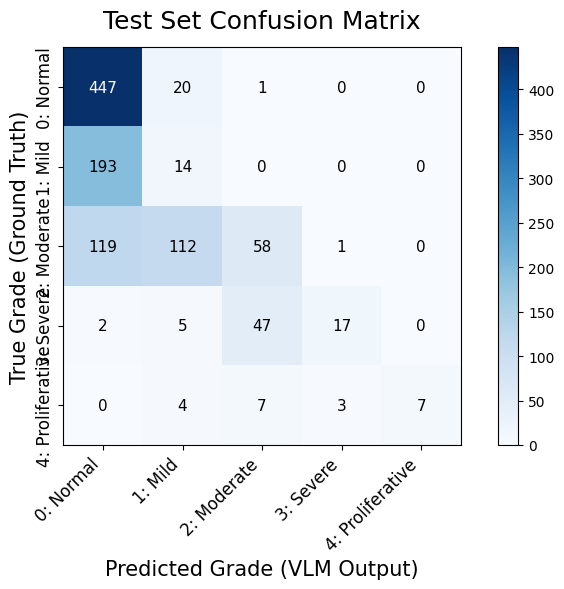

Saved confusion matrix image to: C:\Users\Mohammad\Downloads\DR_Messidor_only_512_CLAHE\confusion_matrix.png


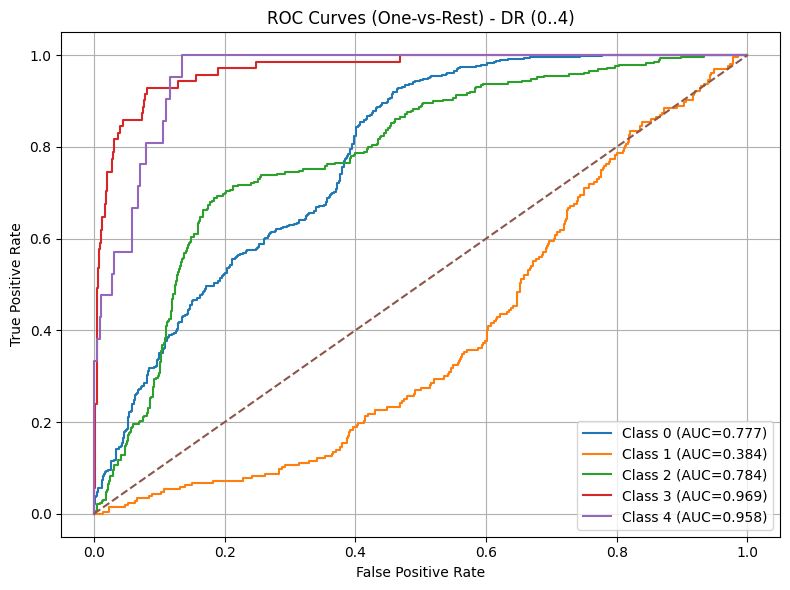


--- Summary (Macro / DR) ---
Accuracy:      0.5137
QWK:           0.5802
AUC-ROC:       0.7744
Precision:     0.6001
Recall:        0.3591
F1 Score:      0.3924


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

df_preds = pd.read_csv(preds_csv)

y_true = df_preds["y_true"].astype(int).to_numpy()
y_score = df_preds[[f"p{i}" for i in range(5)]].to_numpy()
y_pred = y_score.argmax(axis=1)

acc = accuracy_score(y_true, y_pred)
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])

print("\nAccuracy:", round(acc, 4))
print("QWK:", round(qwk, 4))
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)
print(
    "\nClassification report:\n",
    classification_report(y_true, y_pred, labels=[0, 1, 2, 3, 4], digits=4),
)

# Confusion matrix image
class_names = [
    "0: Normal",
    "1: Mild",
    "2: Moderate",
    "3: Severe",
    "4: Proliferative",
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax)

ax.set_title("Test Set Confusion Matrix", fontsize=18, pad=14)
ax.set_xlabel("Predicted Grade (VLM Output)", fontsize=15)
ax.set_ylabel("True Grade (Ground Truth)", fontsize=15)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(class_names, rotation=90, va="center", fontsize=12)

threshold = cm.max() / 2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=11,
        )

fig.tight_layout()
cm_img_path = Path(preds_csv).with_name("confusion_matrix.png")
plt.savefig(cm_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix image to: {cm_img_path}")

# ROC curves (OvR)
y_true_oh = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
for i in range(5):
    if len(np.unique(y_true_oh[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - DR (0..4)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Macro AUC
aucs = []
for i in range(5):
    if len(np.unique(y_true_oh[:, i])) < 2:
        continue
    aucs.append(roc_auc_score(y_true_oh[:, i], y_score[:, i]))

macro_ovr_auc = float(np.mean(aucs)) if len(aucs) else float("nan")

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    digits=4,
    output_dict=True,
)

print("\n--- Summary (Macro / DR) ---")
print(f"Accuracy:      {acc:.4f}")
print(f"QWK:           {qwk:.4f}")
print(f"AUC-ROC:       {macro_ovr_auc:.4f}")
print(f"Precision:     {report['macro avg']['precision']:.4f}")
print(f"Recall:        {report['macro avg']['recall']:.4f}")
print(f"F1 Score:      {report['macro avg']['f1-score']:.4f}")